In [22]:
# 1. Import Libraries
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.decomposition import PCA

from mlxtend.plotting import plot_decision_regions


In [23]:
# =========================
# 2. Load Dataset Automatically
# =========================

# Replace this URL with your own GitHub RAW CSV link

url = "https://raw.githubusercontent.com/kashfihs/lab3_3202_220129/refs/heads/main/KNN/WineQT.csv"

df = pd.read_csv(url)

print(df.head())



   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [24]:
# =========================
# 3. Dataset Information
# =========================

print("\nShape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Info:")
print(df.info())



Shape: (1143, 13)

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 

In [25]:
# 4. Handle Missing Values
# =========================

imputer = SimpleImputer(strategy='mean')

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

In [26]:
# =========================
# 5. Feature and Target Split
# =========================

X = df_imputed.drop('quality', axis=1)
y = df_imputed['quality']



In [27]:
# =========================
# 6. Convert Target into Binary
# =========================

# Good Wine = 1
# Bad Wine = 0

y = np.where(y >= 6, 1, 0)


In [28]:
# =========================
# 7. Train Validation Test Split
# =========================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTraining Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test.shape)



Training Shape: (800, 12)
Validation Shape: (171, 12)
Testing Shape: (172, 12)


In [29]:
# =========================
# 8. Feature Scaling
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

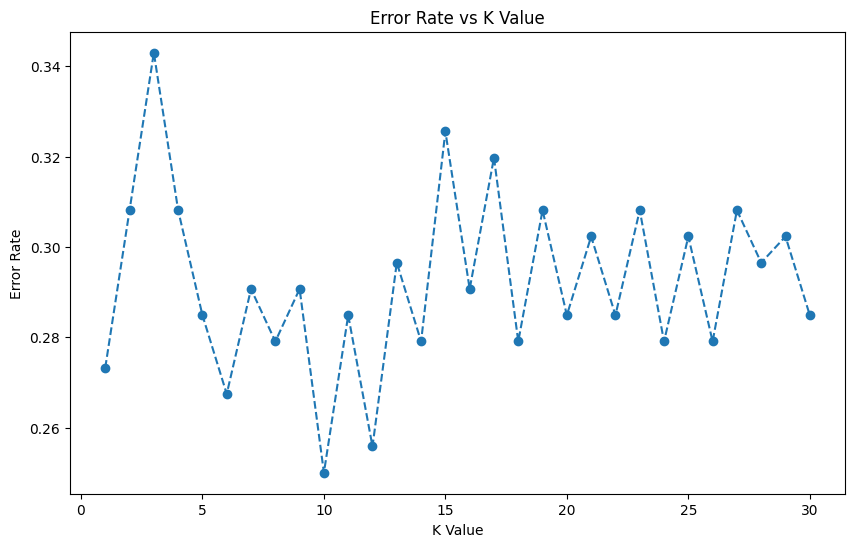

In [30]:
# =========================
# 9. Elbow Method
# =========================

error_rate = []

k_values = range(1, 31)

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    pred_k = knn.predict(X_test)

    error = np.mean(pred_k != y_test)

    error_rate.append(error)

plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    error_rate,
    marker='o',
    linestyle='dashed'
)

plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K Value")

plt.show()

In [31]:
# =========================
# 10. Hyperparameter Tuning
# =========================

param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Accuracy:")
print(grid.best_score_)


Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Best Accuracy:
0.73125


In [32]:
# =========================
# 11. Train Best Model
# =========================

best_knn = grid.best_estimator_

best_knn.fit(X_train, y_train)

# =========================

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [33]:
# 12. Predictions
# =========================

y_pred = best_knn.predict(X_test)

y_prob = best_knn.predict_proba(X_test)[:,1]


In [34]:
# =========================
# 13. Evaluation Metrics
# =========================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc_score = roc_auc_score(y_test, y_prob)

print("\nAccuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

print("AUC Score:", auc_score)


Accuracy: 0.7209302325581395
Precision: 0.7319587628865979
Recall: 0.7634408602150538
F1 Score: 0.7473684210526316
AUC Score: 0.7554103715802369


In [35]:
# =========================
# 14. Classification Report
# =========================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# =========================


Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.67      0.69        79
           1       0.73      0.76      0.75        93

    accuracy                           0.72       172
   macro avg       0.72      0.72      0.72       172
weighted avg       0.72      0.72      0.72       172



In [36]:
# =========================
# 15. Sample Predictions
# =========================

sample_df = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred[:10],
    'Probability': y_prob[:10]
})

print("\nSample Predictions:\n")

print(sample_df)


Sample Predictions:

   Actual  Predicted  Probability
0       1          1     0.896997
1       1          1     1.000000
2       1          0     0.290358
3       0          0     0.354563
4       0          0     0.000000
5       1          0     0.284075
6       0          0     0.001401
7       1          1     0.996798
8       0          0     0.260378
9       0          0     0.335512


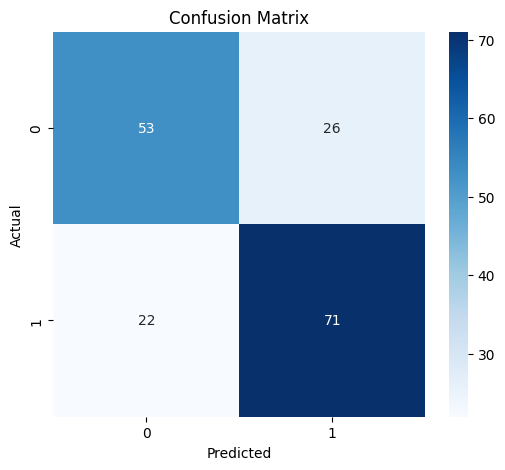

In [37]:
# =========================
# 16. Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

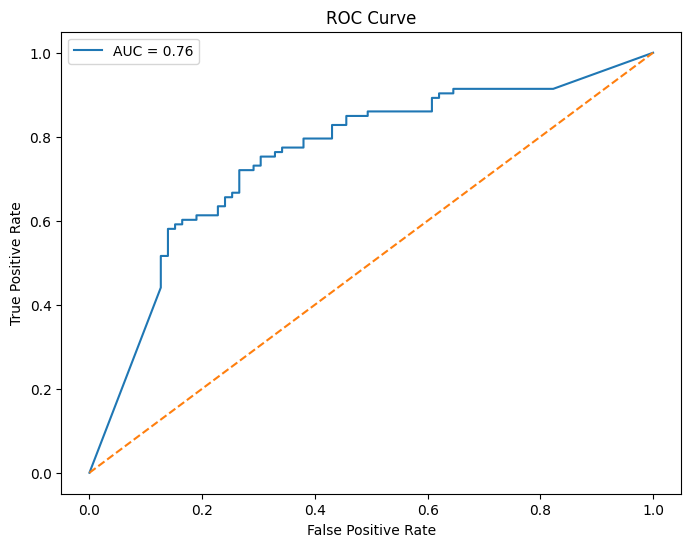

In [38]:
# =========================
# 17. ROC Curve
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

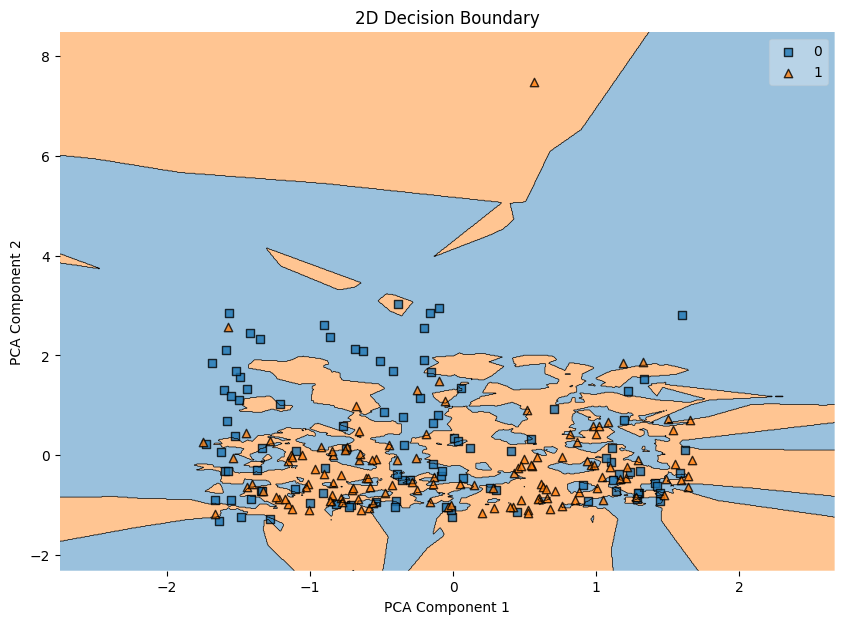

In [39]:
# =========================
# 18. 2D Decision Boundary
# =========================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

scaler2 = StandardScaler()

X_train2 = scaler2.fit_transform(X_train2)

X_test2 = scaler2.transform(X_test2)

model_2d = KNeighborsClassifier(
    n_neighbors=grid.best_params_['n_neighbors']
)

model_2d.fit(X_train2, y_train2)

plt.figure(figsize=(10,7))

plot_decision_regions(
    X_test2,
    y_test2,
    clf=model_2d
)

plt.title("2D Decision Boundary")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.show()

In [40]:
# =========================
# 19. Cross Validation Score
# =========================

cv_scores = cross_val_score(
    best_knn,
    X_train,
    y_train,
    cv=5
)

print("\nCross Validation Scores:")

print(cv_scores)

print("\nAverage CV Score:", cv_scores.mean())


Cross Validation Scores:
[0.68125 0.725   0.79375 0.69375 0.7625 ]

Average CV Score: 0.73125
